In [7]:
import polars as pl
import plotly.io as pio
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Set

In [8]:
pio.renderers.default = "notebook"

## Combinations to be made
- all Specific Occupancy fields (10 fields)
1. type_to_specific
2. NONRESIDENTIAL_SUBTYPE_to_specific
3. DEVELOPMENT_SUBTYPE_to_specific
4. BUILDING_U_to_specific
5. BLDGTYPE_to_specific
6. BLDGSUBTYP_to_specific
7. PRIMARYUSE_to_specific
8. Offices
9. ACTUAL_USE_DESCRIPTION_to_specific
10. MC_subtype_to_specific

Warning: Missing columns: ['BLDG_TYPE_to_specific', 'BLDG_SUBTYP_to_specific', 'PRIMARY_USE_to_specific']

- all General Occupancy fields (4 fields)
1. BUILDING_U_to_general
2. BLDGCLASS_to_general
3. Commercial
4. Residential

These will need a bit more attention... 

In [9]:
df = pl.read_parquet('general_combinations_made.parquet')

In [10]:
df.head()

Residential,building_name,Construction_Typology_Code,Construction_Typology_Description,Commercial,Offices,MANUAL_CLASS_CODE,MANUAL_CLASS_DESCRIPTION,FOUNDATION_TYPE,CARPORTS,ZONING,Shape_Length,Shape_Area,Permanent_ID,hazus_class,type_to_specific,NONRESIDENTIAL_SUBTYPE_to_specific,DEVELOPMENT_SUBTYPE_to_specific,BUILDING_U_to_general,BUILDING_U_to_specific,BLDGCLASS_to_general,BLDGTYPE_to_specific,BLDGSUBTYP_to_specific,PRIMARYUSE_to_specific,ACTUAL_USE_DESCRIPTION_to_specific,MC_age,MC_quality,MC_subtype,MC_subtype_to_specific,year_built,seismic_build_quality,building_area_M2,building_storeys,building_footprint_M2,building_population,building_address
str,str,str,str,str,str,str,str,str,f64,str,f64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,f64,f64,f64,f64,str
null,null,null,null,null,null,"""0090""","""1 STY SFD - After 1930 - Stand…","""Basement""",null,"""RS1""",89.361491,379.778462,1,"""RES1""","""RES1""",null,null,null,null,null,null,null,null,"""RES1""","""After 1930""","""Standard""","""SFD""","""RES1""",1958,"""ordinary""",202.52854,2.0,379.778462,null,"""818 SMITH AVE COQUITLAM V3J 2X…"
null,null,null,null,null,null,"""0157""","""2 STY SFD - After 1990 Semi-Cu…","""Basement""",null,"""RS1""",129.888197,921.070856,2,"""RES1""","""RES1""",null,null,null,null,null,null,null,null,"""RES1""",null,null,"""SFD""","""RES1""",2011,null,662.862905,4.0,921.070856,null,"""846 SMITH AVE COQUITLAM V3J 2X…"
null,null,null,null,null,null,"""0090""","""1 STY SFD - After 1930 - Stand…","""Basement""",1.0,"""RS1""",81.080509,363.529101,3,"""RES1""","""RES1""",null,null,null,null,null,null,null,null,"""RES1""","""After 1930""","""Standard""","""SFD""","""RES1""",1958,"""ordinary""",193.23824,2.0,363.529101,null,"""826 SMITH AVE COQUITLAM V3J 2X…"
null,null,null,null,null,null,"""0155""","""1 STY SFD - After 1990 - Semi-…","""Basement""",null,"""RS1""",120.445506,701.864821,4,"""RES1""","""RES1""",null,null,null,null,null,null,null,null,"""RES1""","""After 1990""","""Semi-Custom""","""SFD""","""RES1""",2008,"""superior""",394.744847,4.0,701.864821,null,"""758 SMITH AVE COQUITLAM V3J 2X…"
null,null,null,null,null,null,"""0145""","""1 STY SFD - After 1990 - Stand…","""Basement""",null,"""RS1""",98.15588,490.537914,5,"""RES1""","""RES1""",null,null,null,null,null,null,null,null,"""RES1""","""After 1990""","""Standard""","""SFD""","""RES1""",1968,"""ordinary""",244.427793,3.0,490.537914,null,"""806 SMITH AVE COQUITLAM V3J 2X…"


### Time for some analysis

COMPREHENSIVE OVERLAP ANALYSIS - SPECIFIC TYPE COLUMNS
Total rows in dataset: 703,185

INDIVIDUAL COLUMN COVERAGE
type_to_specific                            117,205 rows ( 16.7%)
NONRESIDENTIAL_SUBTYPE_to_specific            7,149 rows (  1.0%)
DEVELOPMENT_SUBTYPE_to_specific                 277 rows (  0.0%)
BUILDING_U_to_specific                       54,379 rows (  7.7%)
BLDGTYPE_to_specific                              2 rows (  0.0%)
BLDGSUBTYP_to_specific                            5 rows (  0.0%)
PRIMARYUSE_to_specific                            1 rows (  0.0%)
Offices                                       1,160 rows (  0.2%)
ACTUAL_USE_DESCRIPTION_to_specific          582,927 rows ( 82.9%)
MC_subtype_to_specific                      586,273 rows ( 83.4%)

PAIRWISE OVERLAPS (only showing pairs with overlap > 0)

type_to_specific vs BLDGTYPE_to_specific:
  Both populated:                2
  Only type_to_specific                  117,203
  Only BLDGTYPE_to_specific               

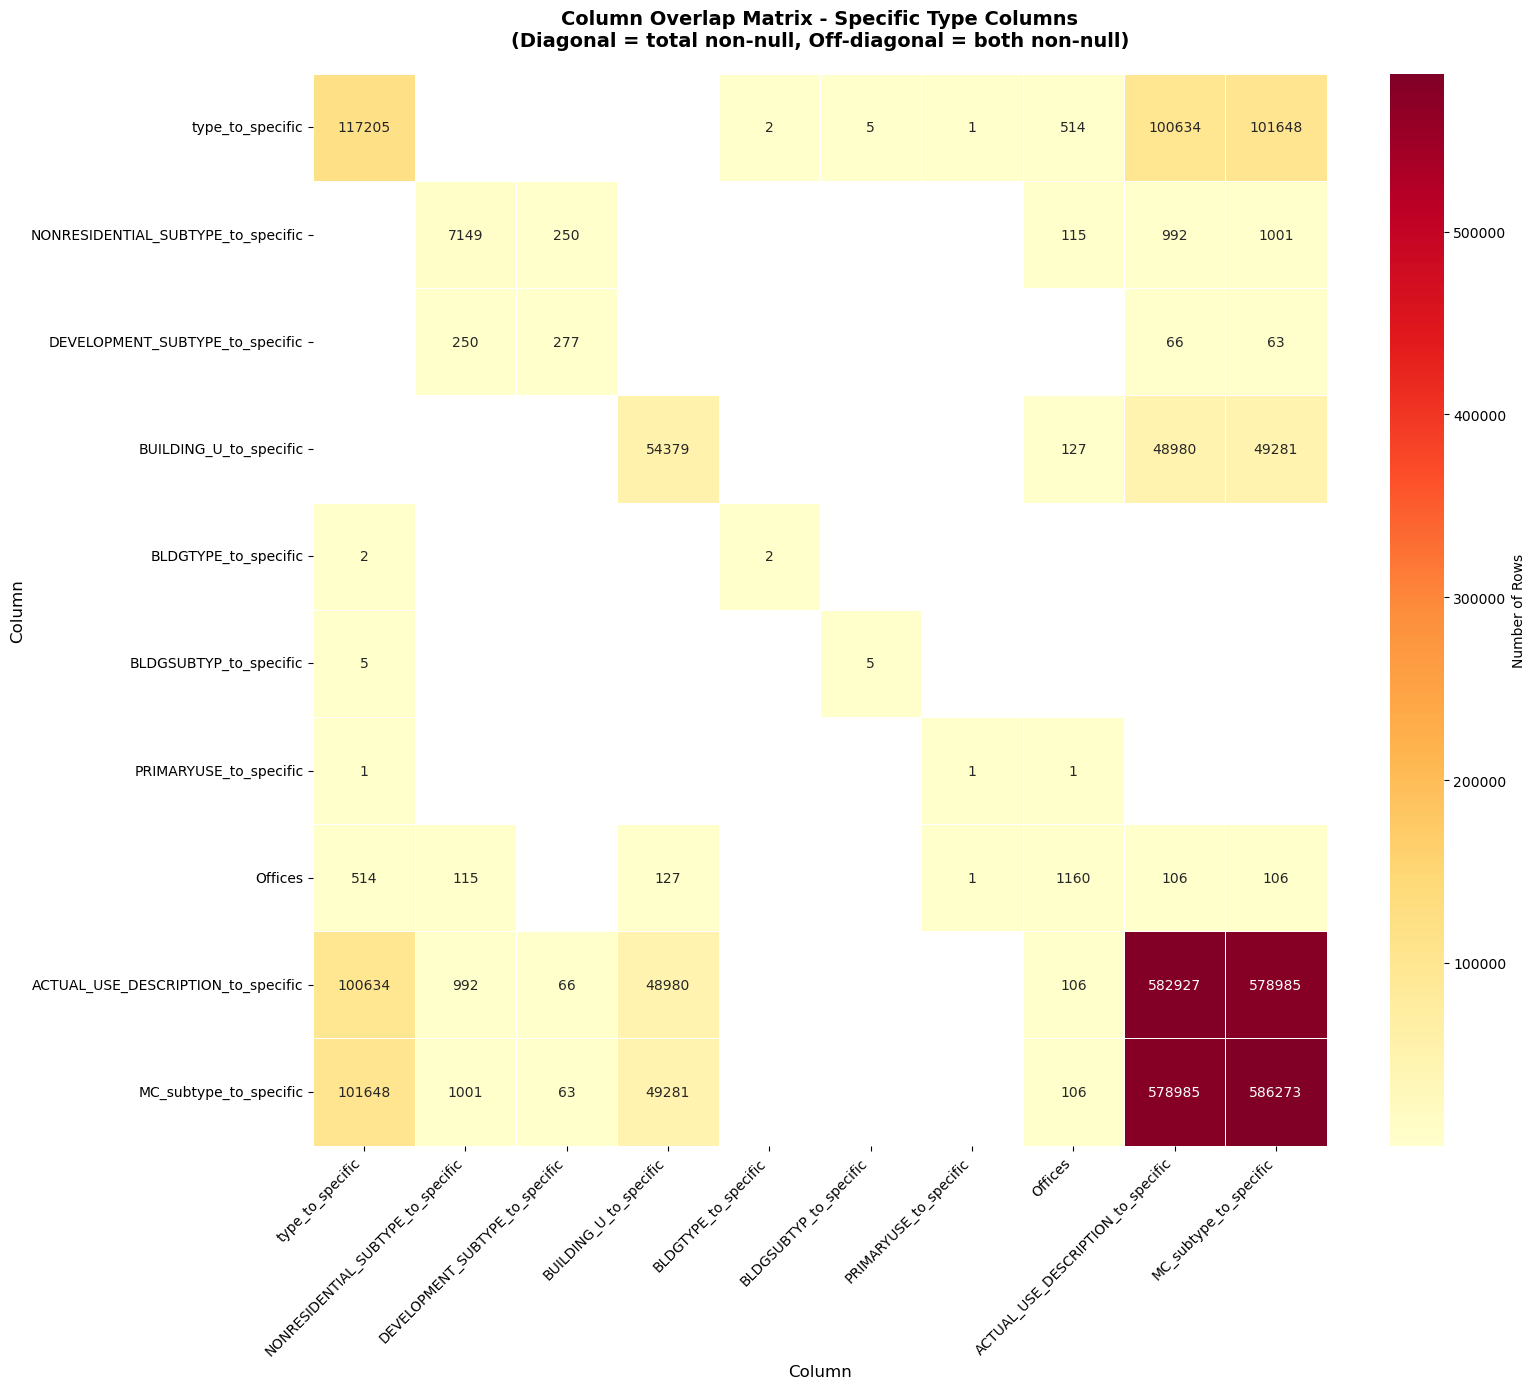

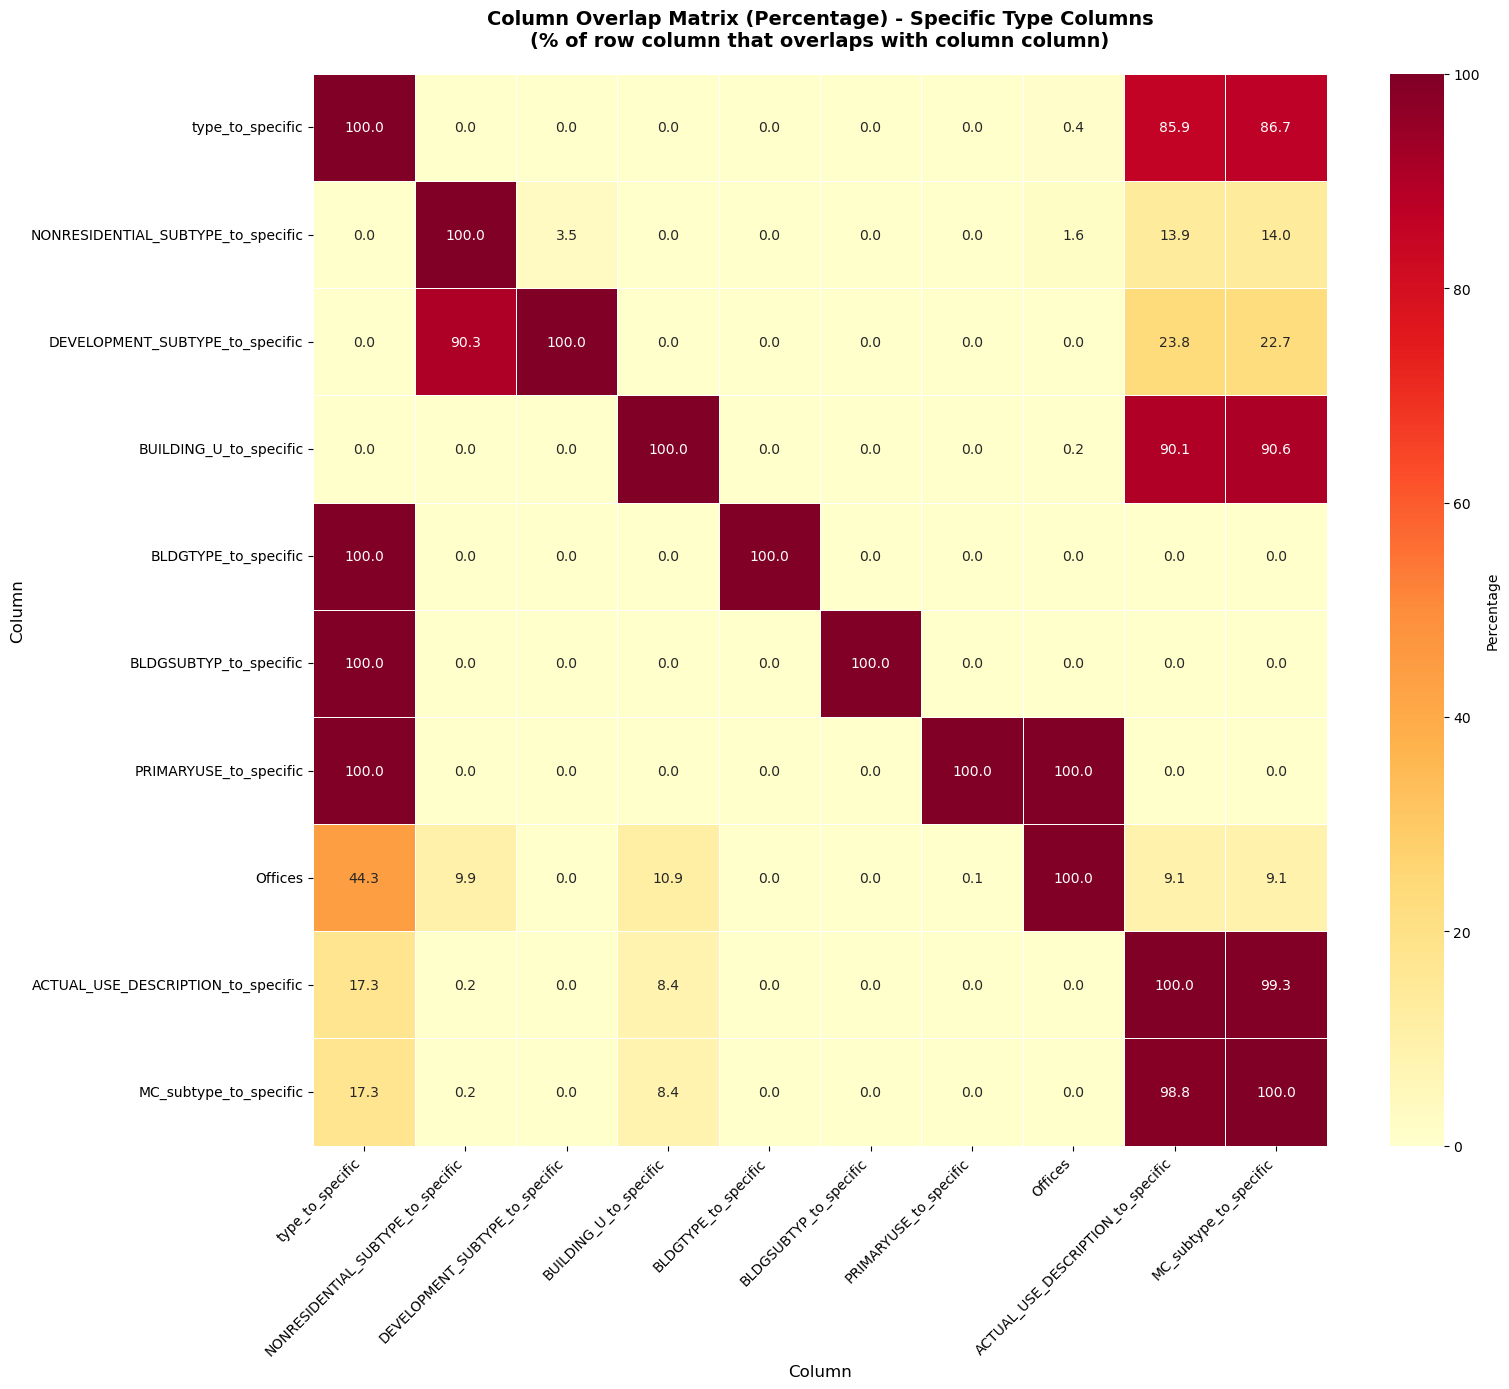

MULTI-WAY OVERLAPS - SPECIFIC TYPE COLUMNS

Three-way overlaps (showing only where all 3 are populated):
--------------------------------------------------------------------------------
type_to_specific                    & PRIMARYUSE_to_specific              & Offices                            :        1
type_to_specific                    & Offices                             & ACTUAL_USE_DESCRIPTION_to_specific :       52
type_to_specific                    & Offices                             & MC_subtype_to_specific             :       52
type_to_specific                    & ACTUAL_USE_DESCRIPTION_to_specific  & MC_subtype_to_specific             :   99,979
NONRESIDENTIAL_SUBTYPE_to_specific  & DEVELOPMENT_SUBTYPE_to_specific     & ACTUAL_USE_DESCRIPTION_to_specific :       64
NONRESIDENTIAL_SUBTYPE_to_specific  & DEVELOPMENT_SUBTYPE_to_specific     & MC_subtype_to_specific             :       61
NONRESIDENTIAL_SUBTYPE_to_specific  & Offices                             & ACTUAL

In [11]:
# Comprehensive overlap analysis for specific type columns
def comprehensive_overlap_analysis(df):
    """
    Analyze overlap across all building classification columns
    """
    cols = [
        'type_to_specific',
        'NONRESIDENTIAL_SUBTYPE_to_specific',
        'DEVELOPMENT_SUBTYPE_to_specific',
        'BUILDING_U_to_specific',
        'BLDGTYPE_to_specific',
        'BLDGSUBTYP_to_specific',
        'PRIMARYUSE_to_specific',
        'Offices',
        'ACTUAL_USE_DESCRIPTION_to_specific',
        'MC_subtype_to_specific'
    ]
    
    # Check which columns exist
    existing_cols = [col for col in cols if col in df.columns]
    missing_cols = [col for col in cols if col not in df.columns]
    
    if missing_cols:
        print(f"Warning: Missing columns: {missing_cols}\n")
    
    cols = existing_cols
    
    print("="*80)
    print("COMPREHENSIVE OVERLAP ANALYSIS - SPECIFIC TYPE COLUMNS")
    print("="*80)
    print(f"Total rows in dataset: {df.height:,}\n")
    
    # 1. Individual column coverage
    print("="*80)
    print("INDIVIDUAL COLUMN COVERAGE")
    print("="*80)
    
    coverage = []
    for col in cols:
        non_null = df.filter(pl.col(col).is_not_null()).height
        pct = (non_null / df.height) * 100
        coverage.append({
            'column': col,
            'non_null_rows': non_null,
            'percentage': pct
        })
        print(f"{col:<40} {non_null:>10,} rows ({pct:>5.1f}%)")
    
    coverage_df = pl.DataFrame(coverage).sort('non_null_rows', descending=True)
    
    # 2. Pairwise overlaps
    print("\n" + "="*80)
    print("PAIRWISE OVERLAPS (only showing pairs with overlap > 0)")
    print("="*80)
    
    overlap_results = []
    
    for i, col1 in enumerate(cols):
        for col2 in cols[i+1:]:
            both = df.filter(
                pl.col(col1).is_not_null() & 
                pl.col(col2).is_not_null()
            ).height
            
            only_1 = df.filter(
                pl.col(col1).is_not_null() & 
                pl.col(col2).is_null()
            ).height
            
            only_2 = df.filter(
                pl.col(col1).is_null() & 
                pl.col(col2).is_not_null()
            ).height
            
            if both > 0:  # Only show if there's overlap
                print(f"\n{col1} vs {col2}:")
                print(f"  Both populated:       {both:>10,}")
                print(f"  Only {col1:<30} {only_1:>10,}")
                print(f"  Only {col2:<30} {only_2:>10,}")
                
                overlap_results.append({
                    'col1': col1,
                    'col2': col2,
                    'both': both,
                    'only_col1': only_1,
                    'only_col2': only_2
                })
    
    if not overlap_results:
        print("\nNo overlapping pairs found! All columns are mutually exclusive.")
    
    # 3. Show unique value counts for each column
    print("\n" + "="*80)
    print("UNIQUE VALUES PER COLUMN")
    print("="*80)
    
    for col in cols:
        unique_count = df.filter(pl.col(col).is_not_null())[col].n_unique()
        print(f"{col:<40} {unique_count:>6} unique values")
    
    return coverage_df, overlap_results

# Run the analysis
coverage_df, overlaps = comprehensive_overlap_analysis(df)


## Detailed Value Distribution for Each Column

def show_value_distributions(df):
    """
    Show top values for each classification column
    """
    cols = [
        'type_to_specific',
        'NONRESIDENTIAL_SUBTYPE_to_specific',
        'DEVELOPMENT_SUBTYPE_to_specific',
        'BUILDING_U_to_specific',
        'BLDGTYPE_to_specific',
        'BLDGSUBTYP_to_specific',
        'PRIMARYUSE_to_specific',
        'Offices',
        'ACTUAL_USE_DESCRIPTION_to_specific',
        'MC_subtype_to_specific'
    ]
    
    existing_cols = [col for col in cols if col in df.columns]
    
    for col in existing_cols:
        print("\n" + "="*80)
        print(f"{col} - Top 20 Values")
        print("="*80)
        
        dist = (df
                .group_by(col)
                .agg(pl.len().alias('count'))
                .sort('count', descending=True)
                .head(20))
        
        print(dist)

show_value_distributions(df)


## Visual Overlap Matrix

def create_overlap_heatmap(df):
    """
    Create heatmap showing overlap between all columns
    """
    cols = [
        'type_to_specific',
        'NONRESIDENTIAL_SUBTYPE_to_specific',
        'DEVELOPMENT_SUBTYPE_to_specific',
        'BUILDING_U_to_specific',
        'BLDGTYPE_to_specific',
        'BLDGSUBTYP_to_specific',
        'PRIMARYUSE_to_specific',
        'Offices',
        'ACTUAL_USE_DESCRIPTION_to_specific',
        'MC_subtype_to_specific'
    ]
    
    existing_cols = [col for col in cols if col in df.columns]
    n = len(existing_cols)
    
    # Create matrix of overlap counts
    overlap_matrix = np.zeros((n, n))
    
    for i, col1 in enumerate(existing_cols):
        for j, col2 in enumerate(existing_cols):
            if i == j:
                # Diagonal: total non-null count
                overlap_matrix[i][j] = df.filter(pl.col(col1).is_not_null()).height
            else:
                # Off-diagonal: both non-null
                overlap_matrix[i][j] = df.filter(
                    pl.col(col1).is_not_null() & 
                    pl.col(col2).is_not_null()
                ).height
    
    # Create heatmap
    plt.figure(figsize=(16, 14))
    
    # Use log scale for better visualization if values vary widely
    mask = overlap_matrix == 0
    
    sns.heatmap(overlap_matrix, 
                annot=True, 
                fmt='.0f',
                xticklabels=existing_cols,
                yticklabels=existing_cols,
                cmap='YlOrRd',
                cbar_kws={'label': 'Number of Rows'},
                linewidths=0.5,
                mask=mask)
    
    plt.title('Column Overlap Matrix - Specific Type Columns\n(Diagonal = total non-null, Off-diagonal = both non-null)', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Column', fontsize=12)
    plt.ylabel('Column', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Also create percentage version
    plt.figure(figsize=(16, 14))
    
    overlap_pct = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if overlap_matrix[i][i] > 0:
                overlap_pct[i][j] = (overlap_matrix[i][j] / overlap_matrix[i][i]) * 100
    
    sns.heatmap(overlap_pct, 
                annot=True, 
                fmt='.1f',
                xticklabels=existing_cols,
                yticklabels=existing_cols,
                cmap='YlOrRd',
                cbar_kws={'label': 'Percentage'},
                linewidths=0.5,
                vmin=0,
                vmax=100)
    
    plt.title('Column Overlap Matrix (Percentage) - Specific Type Columns\n(% of row column that overlaps with column column)', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Column', fontsize=12)
    plt.ylabel('Column', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

create_overlap_heatmap(df)


## Three-way and Higher Overlaps

def analyze_multiway_overlaps(df):
    """
    Check for 3-way, 4-way overlaps etc.
    """
    cols = [
        'type_to_specific',
        'NONRESIDENTIAL_SUBTYPE_to_specific',
        'DEVELOPMENT_SUBTYPE_to_specific',
        'BUILDING_U_to_specific',
        'BLDGTYPE_to_specific',
        'BLDGSUBTYP_to_specific',
        'PRIMARYUSE_to_specific',
        'Offices',
        'ACTUAL_USE_DESCRIPTION_to_specific',
        'MC_subtype_to_specific'
    ]
    
    existing_cols = [col for col in cols if col in df.columns]
    
    print("="*80)
    print("MULTI-WAY OVERLAPS - SPECIFIC TYPE COLUMNS")
    print("="*80)
    
    # Check all possible combinations of 3 columns
    from itertools import combinations
    
    # 3-way overlaps
    print("\nThree-way overlaps (showing only where all 3 are populated):")
    print("-"*80)
    
    three_way_results = []
    for combo in combinations(existing_cols, 3):
        count = df.filter(
            pl.col(combo[0]).is_not_null() & 
            pl.col(combo[1]).is_not_null() & 
            pl.col(combo[2]).is_not_null()
        ).height
        
        if count > 0:
            print(f"{combo[0]:35} & {combo[1]:35} & {combo[2]:35}: {count:>8,}")
            three_way_results.append({
                'columns': f"{combo[0]} & {combo[1]} & {combo[2]}",
                'count': count
            })
    
    if not three_way_results:
        print("No three-way overlaps found.")
    
    # Check how many rows have multiple columns populated
    print("\n" + "="*80)
    print("ROWS WITH MULTIPLE COLUMNS POPULATED")
    print("="*80)
    
    df_with_count = df.with_columns([
        pl.sum_horizontal([
            pl.col(col).is_not_null().cast(pl.Int32) 
            for col in existing_cols
        ]).alias('num_columns_populated')
    ])
    
    multi_col_dist = (df_with_count
                      .group_by('num_columns_populated')
                      .agg(pl.len().alias('count'))
                      .sort('num_columns_populated'))
    
    print(multi_col_dist)
    
    # Show examples of rows with many columns populated
    max_populated = df_with_count['num_columns_populated'].max()
    
    if max_populated > 1:
        print(f"\n" + "="*80)
        print(f"SAMPLE ROWS WITH {max_populated} COLUMNS POPULATED")
        print("="*80)
        
        sample = (df_with_count
                  .filter(pl.col('num_columns_populated') == max_populated)
                  .select(existing_cols)
                  .head(10))
        
        print(sample)

analyze_multiway_overlaps(df)


## Summary Report

def generate_overlap_summary(df):
    """
    Generate comprehensive summary report
    """
    cols = [
        'type_to_specific',
        'NONRESIDENTIAL_SUBTYPE_to_specific',
        'DEVELOPMENT_SUBTYPE_to_specific',
        'BUILDING_U_to_specific',
        'BLDGTYPE_to_specific',
        'BLDGSUBTYP_to_specific',
        'PRIMARYUSE_to_specific',
        'Offices',
        'ACTUAL_USE_DESCRIPTION_to_specific',
        'MC_subtype_to_specific'
    ]
    
    existing_cols = [col for col in cols if col in df.columns]
    
    print("="*80)
    print("EXECUTIVE SUMMARY - SPECIFIC TYPE COLUMNS")
    print("="*80)
    
    # Total coverage
    df_with_any = df.filter(
        pl.any_horizontal([pl.col(col).is_not_null() for col in existing_cols])
    ).height
    
    print(f"\nTotal rows: {df.height:,}")
    print(f"Rows with at least one specific classification: {df_with_any:,} ({df_with_any/df.height*100:.1f}%)")
    print(f"Rows with no specific classification: {df.height - df_with_any:,} ({(df.height - df_with_any)/df.height*100:.1f}%)")
    
    # Find best single column for coverage
    best_col = None
    best_count = 0
    for col in existing_cols:
        count = df.filter(pl.col(col).is_not_null()).height
        if count > best_count:
            best_count = count
            best_col = col
    
    print(f"\nBest single column for coverage: {best_col} ({best_count:,} rows, {best_count/df.height*100:.1f}%)")
    
    # If we consolidate all columns
    df_consolidated = df.with_columns([
        pl.coalesce([pl.col(col) for col in existing_cols]).alias('consolidated')
    ])
    
    consolidated_count = df_consolidated.filter(pl.col('consolidated').is_not_null()).height
    
    print(f"Coverage if consolidated: {consolidated_count:,} rows ({consolidated_count/df.height*100:.1f}%)")
    print(f"Additional coverage gained: {consolidated_count - best_count:,} rows ({(consolidated_count - best_count)/df.height*100:.1f}%)")

generate_overlap_summary(df)
